# 03 — Hiểu dữ liệu AAPL theo thời gian

Notebook này thực hiện **data understanding** và **EDA** cho snapshot AAPL cục bộ đã khóa. Mục tiêu là hiểu đặc điểm chuỗi giá và chuẩn bị cơ sở khái niệm cho task:

> 30 trading days gần nhất → Close của trading day kế tiếp.

Giới hạn của notebook:

- chỉ đọc `datasets/stock/AAPL_2015_2025.csv`;
- không gọi `yfinance` hoặc bất kỳ nguồn dữ liệu trực tuyến nào;
- không tạo production split/scaler/window files;
- không train RNN và không đưa ra khuyến nghị đầu tư.


## Thiết lập

Figures tái sử dụng được lưu vào `results/figures/stock_eda/`. `SEED = 42` được giữ theo experiment contract, dù các phép EDA trong notebook này không dùng sampling ngẫu nhiên.


In [1]:
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import FuncFormatter

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

STOCK_PATH = PROJECT_ROOT / "datasets" / "stock" / "AAPL_2015_2025.csv"
FIGURE_DIR = PROJECT_ROOT / "results" / "figures" / "stock_eda"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_COLUMNS = ["Date", "Open", "High", "Low", "Close", "Adj Close", "Volume"]
MODEL_FEATURES = ["Open", "High", "Low", "Close", "Volume"]
SEQUENCE_LENGTH = 30

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

assert STOCK_PATH.is_file(), f"Không tìm thấy locked CSV: {STOCK_PATH}"
print(f"Python executable: {sys.executable}")
print(f"Locked stock CSV: {STOCK_PATH}")
print(f"Figure directory: {FIGURE_DIR}")

Python executable: C:\Users\anhca\anaconda3\envs\rnn312\python.exe
Locked stock CSV: C:\DATA\assign\A06\datasets\stock\AAPL_2015_2025.csv
Figure directory: C:\DATA\assign\A06\results\figures\stock_eda


## 1. Mô tả dataset

Mỗi row là một trading day của AAPL:

| Cột         | Ý nghĩa trực giác                                                                                |
| ----------- | ------------------------------------------------------------------------------------------------ |
| `Date`      | ngày giao dịch                                                                                   |
| `Open`      | giá khi phiên mở cửa                                                                             |
| `High`      | giá cao nhất trong phiên                                                                         |
| `Low`       | giá thấp nhất trong phiên                                                                        |
| `Close`     | giá khi phiên đóng cửa                                                                           |
| `Adj Close` | chuỗi đóng cửa đã được nguồn dữ liệu điều chỉnh cho các corporate actions theo quy ước của nguồn |
| `Volume`    | số cổ phiếu được giao dịch trong phiên                                                           |

**OHLC** là viết tắt của Open–High–Low–Close. Có thể hình dung một phiên như sau: giá bắt đầu ở `Open`, dao động trong khoảng từ `Low` đến `High`, rồi kết thúc ở `Close`.

Snapshot được tải một lần với `auto_adjust=False`, nên `Open/High/Low/Close` được giữ thành các cột OHLC riêng và `Adj Close` không tự động thay thế chúng. Task A06 dùng `Close`, không dùng `Adj Close` làm input hay target.


## 2. Data audit

Ta đọc đúng CSV cục bộ, giữ lại dtypes ban đầu để audit, sau đó parse `Date` và các cột số trong memory. Các kiểm tra invalid price gồm giá không dương và quan hệ OHLC bất hợp lý (`High` phải không nhỏ hơn các mức còn lại; `Low` phải không lớn hơn các mức còn lại).


In [ ]:
raw_stock = pd.read_csv(STOCK_PATH)
raw_dtypes = raw_stock.dtypes.astype(str).rename("raw_dtype").to_frame()

assert (
    raw_stock.columns.tolist() == EXPECTED_COLUMNS
), f"Schema không đúng: {raw_stock.columns.tolist()}"

stock = raw_stock.copy()
stock["Date"] = pd.to_datetime(stock["Date"], errors="coerce")
numeric_columns = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
for column in numeric_columns:
    stock[column] = pd.to_numeric(stock[column], errors="coerce")

parsed_dtypes = stock.dtypes.astype(str).rename("parsed_dtype").to_frame()
dtype_audit = raw_dtypes.join(parsed_dtypes)

price_columns = ["Open", "High", "Low", "Close", "Adj Close"]
nonpositive_price_by_column = stock[price_columns].le(0).sum()
any_nonpositive_price = stock[price_columns].le(0).any(axis=1)
high_violation = stock["High"] < stock[["Open", "Low", "Close"]].max(axis=1)
low_violation = stock["Low"] > stock[["Open", "High", "Close"]].min(axis=1)

audit_summary = pd.Series(
    {
        "rows": len(stock),
        "columns": stock.shape[1],
        "invalid_or_missing_dates": int(stock["Date"].isna().sum()),
        "duplicate_dates": int(stock["Date"].duplicated().sum()),
        "chronological_before_sort": bool(stock["Date"].is_monotonic_increasing),
        "rows_with_nonpositive_price": int(any_nonpositive_price.sum()),
        "rows_with_invalid_high": int(high_violation.sum()),
        "rows_with_invalid_low": int(low_violation.sum()),
        "rows_with_nonpositive_volume": int(stock["Volume"].le(0).sum()),
        "actual_first_trading_date": stock["Date"].min(),
        "actual_last_trading_date": stock["Date"].max(),
    },
    name="value",
)
missing_summary = stock.isna().sum().rename("missing_count").to_frame()

print(f"Raw shape: {raw_stock.shape}")
print("Columns:", raw_stock.columns.tolist())
display(dtype_audit)
display(missing_summary)
display(audit_summary.to_frame())
display(nonpositive_price_by_column.rename("nonpositive_count").to_frame())
display(stock.head(3))

Raw shape: (2766, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


,raw_dtype,parsed_dtype
Date,str,datetime64[us]
Open,float64,float64
High,float64,float64
Low,float64,float64
Close,float64,float64
Adj Close,float64,float64
Volume,int64,int64


,missing_count
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


,value
rows,2766
columns,7
invalid_or_missing_dates,0
duplicate_dates,0
chronological_before_sort,True
rows_with_nonpositive_price,0
rows_with_invalid_high,0
rows_with_invalid_low,0
rows_with_nonpositive_volume,0
actual_first_trading_date,2015-01-02 00:00:00


,nonpositive_count
Open,0
High,0
Low,0
Close,0
Adj Close,0


,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-02,27.8475,27.8600,26.8375,27.3325,24.1718,212818400
1,2015-01-05,27.0725,27.1625,26.3525,26.5625,23.4908,257142000
2,2015-01-06,26.6350,26.8575,26.1575,26.5650,23.4930,263188400


**Integrity findings**

- CSV có 2.766 rows và đúng 7 columns đã khóa.
- Không có missing values, duplicate dates, giá không dương, OHLC inconsistency hoặc non-positive Volume.
- Dữ liệu nguồn đã ở thứ tự tăng dần theo ngày; notebook vẫn sort và assert tường minh ở bước tiếp theo.
- Khoảng calendar yêu cầu là 2015-01-01 đến 2025-12-31. Ngày giao dịch thực tế đầu tiên là **2015-01-02** vì 2015-01-01 không có phiên; ngày cuối là **2025-12-31**.


## 3. Sắp xếp theo thời gian tăng dần

Mọi window và target sau này phụ thuộc row order. Vì vậy ta không dựa vào thứ tự tình cờ của file mà chủ động sort, reset index và assert tính đơn điệu.


In [3]:
stock = stock.sort_values("Date", kind="stable").reset_index(drop=True)

assert stock["Date"].is_monotonic_increasing
assert not stock["Date"].duplicated().any()
assert stock["Date"].min() >= pd.Timestamp("2015-01-01")
assert stock["Date"].max() <= pd.Timestamp("2025-12-31")

print("Chronological assertion: PASS")
print("First trading date:", stock["Date"].iloc[0].date())
print("Last trading date: ", stock["Date"].iloc[-1].date())
print("Trading-day rows:  ", f"{len(stock):,}")

Chronological assertion: PASS
First trading date: 2015-01-02
Last trading date:  2025-12-31
Trading-day rows:   2,766


## 4. Thống kê cơ bản

Bảng thống kê tập trung vào 5 model features đã khóa: `Open`, `High`, `Low`, `Close`, `Volume`. Percentiles giúp thấy scale và độ lệch mà mean/standard deviation đơn lẻ có thể che khuất.


In [ ]:
basic_statistics = (
    stock[MODEL_FEATURES].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
)
display(basic_statistics)

intraday_range_pct = 100 * (stock["High"] - stock["Low"]) / stock["Open"]
print("Intraday range (% Open) — median:", f"{intraday_range_pct.median():.2f}%")
print(
    "Intraday range (% Open) — 99th percentile:",
    f"{intraday_range_pct.quantile(0.99):.2f}%",
)

,count,mean,std,min,1%,25%,50%,75%,99%,max
Open,"2,766.0000",108.5470,73.7776,22.5000,23.7105,39.1600,91.1763,170.9550,271.3790,286.2000
High,"2,766.0000",109.7215,74.5611,22.9175,24.0013,39.4606,92.4075,172.6350,274.1010,288.6200
Low,"2,766.0000",107.4625,73.0723,22.3675,23.4790,38.7656,90.2837,169.3525,269.5740,283.3000
Close,"2,766.0000",108.6449,73.8562,22.5850,23.7475,39.0806,91.2050,170.8300,271.8470,286.1900
Volume,"2,766.0000","111,399,353.0730","68,042,425.6425","17,910,600.0000","32,601,600.0000","64,889,625.0000","94,543,800.0000","137,293,700.0000","365,184,580.0000","648,825,200.0000"


Intraday range (% Open) — median: 1.72%
Intraday range (% Open) — 99th percentile: 6.43%


`Volume` có scale lớn hơn nhiều so với các price features. Price level cũng thay đổi mạnh trong 11 năm, nên một scaler fit đúng cách sẽ cần thiết cho RNN. Extreme volume hoặc biên độ ngày lớn không tự động là lỗi; chúng cần được hiểu trong bối cảnh thị trường và không nên bị xóa chỉ vì là outlier thống kê.


## 5. Visualizations

### 5.1 Close và trading Volume toàn giai đoạn

Hai panels dùng chung trục thời gian nhưng giữ hai đơn vị riêng: USD/cổ phiếu và số cổ phiếu giao dịch.


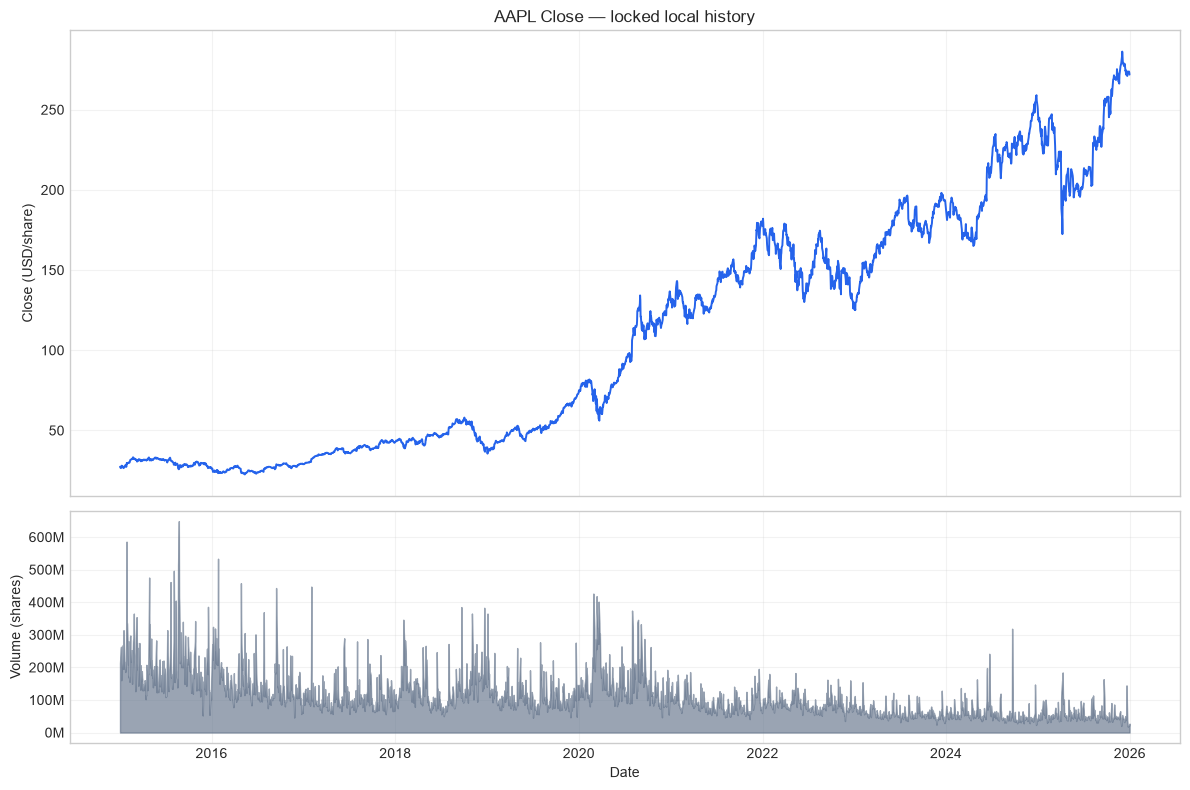

Đã lưu: C:\DATA\assign\A06\results\figures\stock_eda\close_volume_history.png


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, height_ratios=[2, 1])

axes[0].plot(stock["Date"], stock["Close"], color="#2563EB", linewidth=1.4)
axes[0].set(title="AAPL Close — locked local history", ylabel="Close (USD/share)")
axes[0].grid(alpha=0.25)

axes[1].fill_between(stock["Date"], stock["Volume"], color="#64748B", alpha=0.65)
axes[1].set(xlabel="Date", ylabel="Volume (shares)")
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value / 1e6:.0f}M"))
axes[1].grid(alpha=0.25)

fig.tight_layout()
output_path = FIGURE_DIR / "close_volume_history.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

**Nhận xét:** Close có xu hướng tăng dài hạn nhưng không tăng đều; drawdown và các giai đoạn dao động lớn xuất hiện xuyên suốt. Volume tạo các spikes ngắn hạn và có scale khác hẳn price, củng cố nhu cầu scaling theo feature.

### 5.2 OHLC trong một khoảng thời gian dễ đọc

Toàn bộ 2.766 ngày sẽ làm bốn đường OHLC chồng lấn. Ta chọn Q4/2025 để quan sát khoảng `Low–High` cùng `Open` và `Close` mà không biến chart thành nhiễu. Đây chỉ là zoom EDA, không phải chọn giai đoạn model.


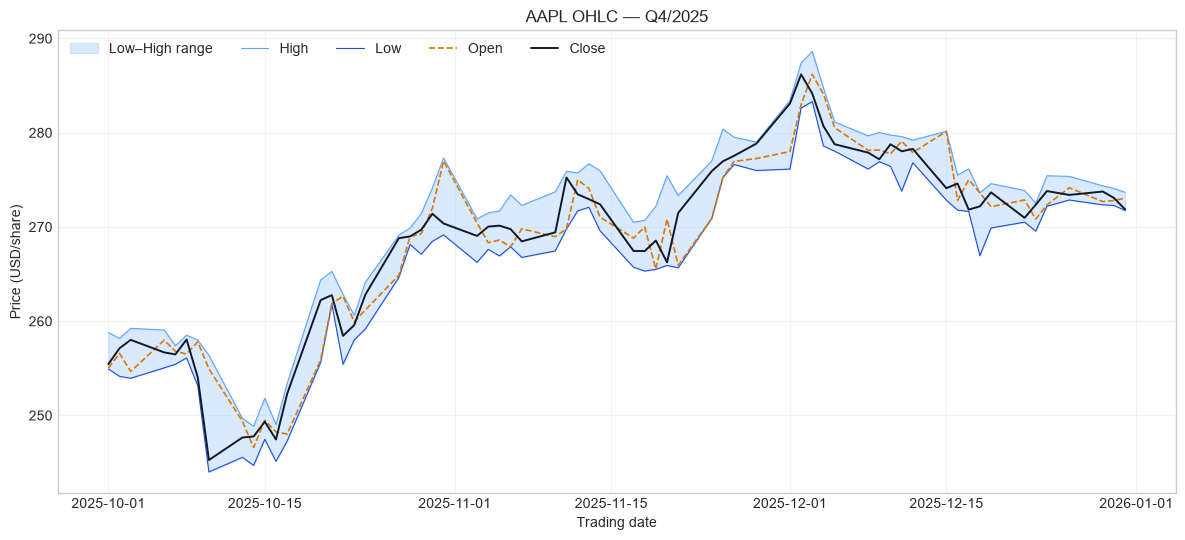

Selected trading rows: 64
Đã lưu: C:\DATA\assign\A06\results\figures\stock_eda\ohlc_q4_2025.png


In [ ]:
interval_start = pd.Timestamp("2025-10-01")
interval_end = pd.Timestamp("2025-12-31")
ohlc_interval = stock.loc[stock["Date"].between(interval_start, interval_end)].copy()
assert not ohlc_interval.empty

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.fill_between(
    ohlc_interval["Date"],
    ohlc_interval["Low"],
    ohlc_interval["High"],
    color="#93C5FD",
    alpha=0.35,
    label="Low–High range",
)
ax.plot(
    ohlc_interval["Date"],
    ohlc_interval["High"],
    color="#60A5FA",
    linewidth=0.8,
    label="High",
)
ax.plot(
    ohlc_interval["Date"],
    ohlc_interval["Low"],
    color="#1D4ED8",
    linewidth=0.8,
    label="Low",
)
ax.plot(
    ohlc_interval["Date"],
    ohlc_interval["Open"],
    color="#D97706",
    linewidth=1.2,
    linestyle="--",
    label="Open",
)
ax.plot(
    ohlc_interval["Date"],
    ohlc_interval["Close"],
    color="#111827",
    linewidth=1.4,
    label="Close",
)
ax.set(
    title="AAPL OHLC — Q4/2025",
    xlabel="Trading date",
    ylabel="Price (USD/share)",
)
ax.legend(ncol=5, loc="upper left")
ax.grid(alpha=0.25)
fig.tight_layout()
output_path = FIGURE_DIR / "ohlc_q4_2025.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Selected trading rows: {len(ohlc_interval)}")
print(f"Đã lưu: {output_path}")

**Nhận xét:** `High` và `Low` tạo biên độ nội phiên; `Open` và `Close` nằm trong khoảng này. Khoảng cách và hướng giữa Open–Close thay đổi từng ngày, cho thấy cùng một price level có thể đi kèm động lực nội phiên khác nhau.

### 5.3 Moving averages 7 và 30 periods

Một period ở đây là một **trading observation**, không phải một calendar day. MA(7) phản ứng nhanh hơn; MA(30) mượt hơn và trễ hơn. Hai đường chỉ giúp đọc trend trong EDA và **không phải model features đã khóa**.


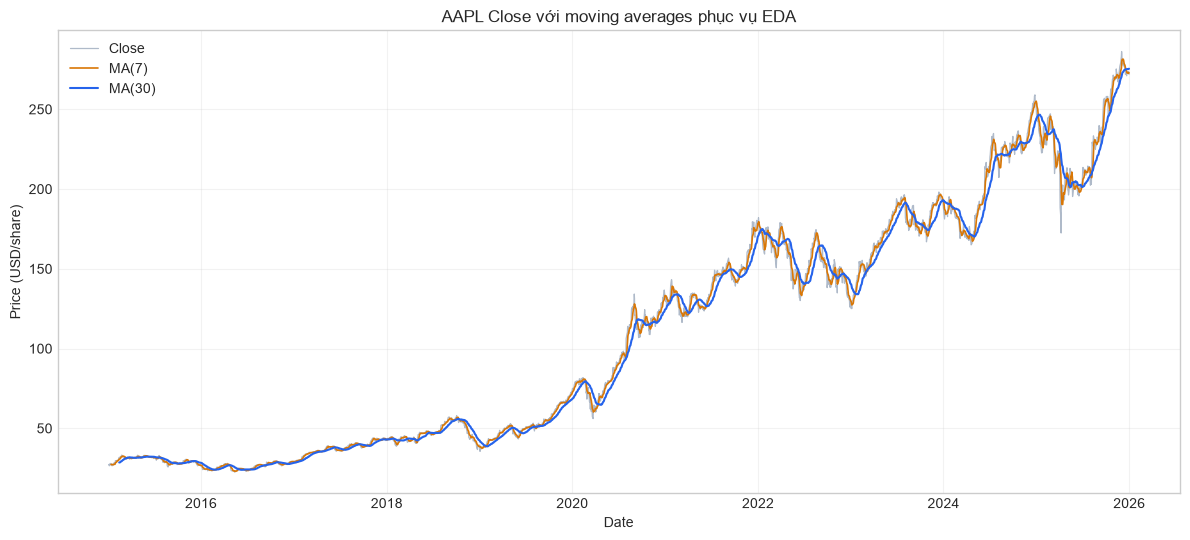

Đã lưu: C:\DATA\assign\A06\results\figures\stock_eda\close_moving_averages.png


In [ ]:
stock_eda = stock.copy()
stock_eda["MA_7"] = stock_eda["Close"].rolling(window=7, min_periods=7).mean()
stock_eda["MA_30"] = stock_eda["Close"].rolling(window=30, min_periods=30).mean()

fig, ax = plt.subplots(figsize=(12, 5.5))
ax.plot(
    stock_eda["Date"],
    stock_eda["Close"],
    color="#94A3B8",
    linewidth=0.9,
    alpha=0.75,
    label="Close",
)
ax.plot(
    stock_eda["Date"], stock_eda["MA_7"], color="#D97706", linewidth=1.2, label="MA(7)"
)
ax.plot(
    stock_eda["Date"],
    stock_eda["MA_30"],
    color="#2563EB",
    linewidth=1.5,
    label="MA(30)",
)
ax.set(
    title="AAPL Close với moving averages phục vụ EDA",
    xlabel="Date",
    ylabel="Price (USD/share)",
)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
output_path = FIGURE_DIR / "close_moving_averages.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

**Nhận xét:** đường trung bình làm rõ xu hướng cục bộ nhưng dùng cả quan sát hiện tại trong chính giá trị MA tại ngày đó. Nếu một feature rolling được thêm ở tương lai, việc căn thời gian phải được kiểm tra chống leakage. Với contract hiện tại, input vẫn chỉ gồm `Open`, `High`, `Low`, `Close`, `Volume`.

### 5.4 Phân phối daily percentage return

Daily return được tính cho EDA bằng:

$$r_t = \left(\frac{Close_t}{Close_{t-1}} - 1\right)\times100\%$$

Return tập trung quanh 0 nhưng có tails, giúp nhìn volatility rõ hơn price level.


,DailyReturnPct
count,"2,765.0000"
mean,0.0996
std,1.8177
min,-12.8647
1%,-4.8073
5%,-2.7201
25%,-0.7395
50%,0.0899
75%,0.9890
95%,2.8372


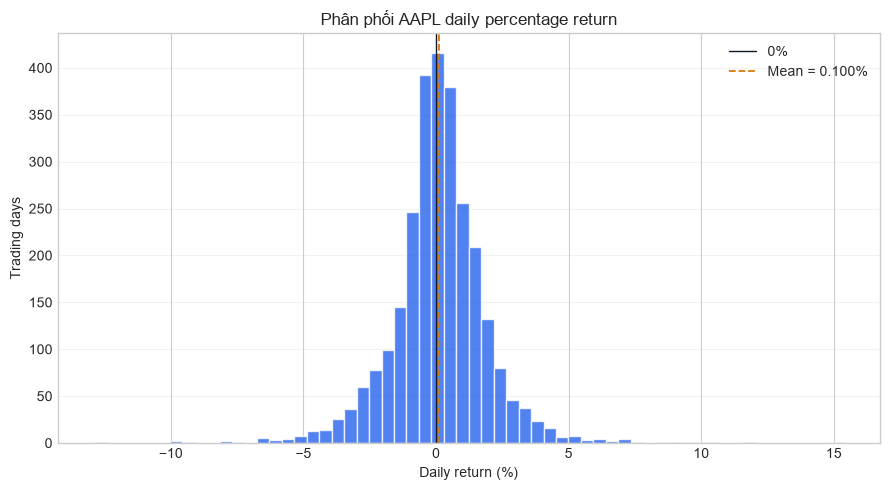

Đã lưu: C:\DATA\assign\A06\results\figures\stock_eda\daily_return_distribution.png


In [ ]:
stock_eda["DailyReturnPct"] = stock_eda["Close"].pct_change(fill_method=None) * 100
daily_returns = stock_eda["DailyReturnPct"].dropna()

display(
    daily_returns.describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .rename("DailyReturnPct")
    .to_frame()
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(daily_returns, bins=60, color="#2563EB", alpha=0.8, edgecolor="white")
ax.axvline(0, color="#111827", linewidth=1.0, label="0%")
ax.axvline(
    daily_returns.mean(),
    color="#D97706",
    linewidth=1.3,
    linestyle="--",
    label=f"Mean = {daily_returns.mean():.3f}%",
)
ax.set(
    title="Phân phối AAPL daily percentage return",
    xlabel="Daily return (%)",
    ylabel="Trading days",
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
output_path = FIGURE_DIR / "daily_return_distribution.png"
fig.savefig(output_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Đã lưu: {output_path}")

**Nhận xét:** phần lớn returns nằm gần 0, nhưng vẫn có ngày tăng/giảm lớn. Volatility không cố định; các ngày dao động mạnh thường có thể xuất hiện theo cụm. Price level và return trả lời hai câu hỏi khác nhau: price thể hiện scale/trend, return thể hiện thay đổi tương đối.


## 6. Đặc điểm của stock time-series

- **Trend:** price level thay đổi dài hạn, nên mean/variance của `Close` không cố định theo toàn bộ giai đoạn.
- **Volatility:** biên độ biến động thay đổi theo thời gian; yên ắng và biến động mạnh có thể xuất hiện thành cụm.
- **Non-stationary scale:** cùng một thay đổi tuyệt đối có ý nghĩa tương đối khác nhau ở mức giá 30 USD và 250 USD.
- **Temporal dependence:** giá ở các ngày gần nhau thường liên quan mạnh; đó là lý do window 30 trading days có ý nghĩa.
- **Khó dự báo chính xác:** giá phản ứng với thông tin mới, kỳ vọng và regime changes mà OHLCV quá khứ không quan sát đầy đủ. Một model phức tạp không loại bỏ sự bất định này.

Notebook chỉ phân tích dữ liệu lịch sử phục vụ học máy, không đưa ra khuyến nghị mua/bán hay tuyên bố khả năng sinh lời.


## 7. Locked RNN task

Mỗi sample có:

- input shape: **`(30, 5)`**;
- 30 rows là 30 trading days liên tiếp;
- 5 features theo đúng thứ tự: `Open`, `High`, `Low`, `Close`, `Volume`;
- target: `Close` của trading day ngay sau cửa sổ;
- task: **regression** vì target là một giá trị liên tục.

Với batch size 32, tensor input cho RNN có shape `(32, 30, 5)` khi dùng `batch_first=True`.


## 8. Minh họa sliding-window

Window chỉ lấy quá khứ. Với indexing theo row đã sort:

```text
days 1..30  → Close day 31
days 2..31  → Close day 32
days 3..32  → Close day 33
...
```

Code dưới đây chỉ tạo ba preview records và một array shape minh họa; chưa lưu production sequences.


In [9]:
window_preview = []
for start_index in range(3):
    end_index = start_index + SEQUENCE_LENGTH
    feature_slice = stock.iloc[start_index:end_index]
    target_row = stock.iloc[end_index]

    assert feature_slice["Date"].max() < target_row["Date"]
    window_preview.append(
        {
            "input_rows": f"{start_index + 1}..{end_index}",
            "input_date_start": feature_slice["Date"].iloc[0].date(),
            "input_date_end": feature_slice["Date"].iloc[-1].date(),
            "target_row": end_index + 1,
            "target_date": target_row["Date"].date(),
            "target_close": target_row["Close"],
            "naive_last_close": feature_slice["Close"].iloc[-1],
        }
    )

first_input = stock.loc[: SEQUENCE_LENGTH - 1, MODEL_FEATURES].to_numpy()
first_target = stock.loc[SEQUENCE_LENGTH, "Close"]

display(pd.DataFrame(window_preview))
print("First input shape:", first_input.shape)
print("First target scalar:", f"{first_target:.4f}")

,input_rows,input_date_start,input_date_end,target_row,target_date,target_close,naive_last_close
0,1..30,2015-01-02,2015-02-13,31,2015-02-17,31.9575,31.7700
1,2..31,2015-01-05,2015-02-17,32,2015-02-18,32.1800,31.9575
2,3..32,2015-01-06,2015-02-18,33,2015-02-19,32.1125,32.1800


First input shape: (30, 5)
First target scalar: 31.9575


Việc kiểm tra `max(input Date) < target Date` bảo đảm target không nằm trong input. Production pipeline sau này phải gắn mỗi sample với `target_date`, vì split sẽ dựa trên ngày target chứ không dựa trên row ngẫu nhiên.

## 9. Chronological split

`train_test_split(..., shuffle=True)` là sai cho chuỗi thời gian vì nó trộn future samples vào train và past samples vào validation/test. Model có thể học scale hoặc regime từ tương lai, tạo kết quả quá lạc quan.

```text
PAST --------------------------------------------------------> FUTURE
|---------------- TRAIN ----------------|---- VAL ----|---- TEST ----|
                    ~70%                    ~15%          ~15%
```

Sample phải được xếp theo **target date**. Mọi train targets đứng trước validation targets; mọi validation targets đứng trước test targets. Exact boundary dates chưa được khóa trong notebook EDA này và sẽ được xác định khi production windows được tạo.


## 10. Scaling không gây leakage

Scaling cần thiết vì `Volume` có thể ở hàng chục/hàng trăm triệu, trong khi price features ở scale hàng chục/hàng trăm. Nếu không scale, feature lớn về đơn vị có thể chi phối gradient.

Quy trình bắt buộc:

1. tạo windows và gắn `target_date`;
2. split theo thời gian;
3. **fit feature scaler chỉ trên các quan sát thuộc TRAIN**;
4. validation/test chỉ gọi `transform()` bằng scaler đã fit;
5. nếu target được scale, target scaler cũng chỉ fit trên TRAIN targets và predictions phải inverse-transform trước khi báo cáo MAE/RMSE theo đơn vị giá.

Notebook này không fit scaler để tránh biến EDA thành production preprocessing.


## 11. Naive persistence baseline

Baseline đơn giản cho mỗi cửa sổ:

$$\widehat{Close}_{t+1} = Close_t$$

Tức là dự đoán Close ngày kế tiếp gần bằng Close cuối cùng đã quan sát trong 30-day window. Cột `naive_last_close` trong bảng preview minh họa đúng quy tắc này.

Stock prices liên tiếp thường rất gần nhau, nên baseline này có thể có absolute error thấp dù không “hiểu” thị trường. RNN chỉ có ý nghĩa thực nghiệm nếu được đánh giá trên cùng test period và so sánh công bằng với naive baseline; low error tự thân chưa đủ chứng minh giá trị.


## 12. Evaluation metrics

Với $n$ targets thật $y_i$ và predictions $\hat{y}_i$:

**MAE — Mean Absolute Error**

$$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|$$

- dễ diễn giải theo đơn vị giá sau inverse scaling;
- mỗi sai số đóng góp tuyến tính nên ít nhạy với outlier hơn RMSE.

**RMSE — Root Mean Squared Error**

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}$$

- phạt sai số lớn mạnh hơn MAE;
- vẫn có cùng đơn vị với target.

**$R^2$ — Coefficient of Determination**

$$R^2 = 1 - \frac{\sum_i(y_i-\hat{y}_i)^2}{\sum_i(y_i-\bar{y})^2}$$

- so sánh squared error với baseline dự đoán mean của evaluation set;
- $R^2=1$ là hoàn hảo, $R^2=0$ ngang baseline mean và $R^2<0$ có thể xảy ra khi model tệ hơn baseline mean.

Các metrics phải được tính trên test set chỉ sau khi model selection hoàn tất. Cần báo cáo cả RNN lẫn naive persistence baseline trên cùng targets; không dùng test để chọn hyperparameters hay early stopping.
